# Example of cut and flow (CnF) analysis

The purposes here are:
- to show how to use the wrapper functions allowing tha analysis of CnF experiments
- to illustarte how it is important to consider water and solutes transport in some water stress cases to avoid significative error on hydraulic parameters.

CnF experiment protocol is described  in [Boursiac et al.](https://doi.org/10.1093/plphys/kiac281). In this work, experiments were performed on Arabidopsis in control condition only therefore analysis was done with the pure water solver of HydroRoot. A second publication, [Bauget et al. 2023](https://doi.org/10.1093/jxb/erac471) was focused on the phenotypage of maize roots under water stress. The authors showed that in this condition solute transport had to be accounting for CnF analysis.

## Inputs

There are 3 kinds of input files:

- a yaml file with general and mandatory parameters see [documentation](https://hydroroot.readthedocs.io/en/latest/user/api_init_parameter.html) for details, or example of files in the `example` directory that are well commented.
- a `csv` file with CnF data mandatory for any CnF analysis, for example `example/data/maize_cnf_data.csv`.
- a `csv` file with flux vs pressure (JvP) needed only with the solute-water solver, for example `example/data/maize_JvP_data.csv`.

#### cnf_data.csv

csv file containing data of cut and flow data of with the following columns:

- arch: sample name that must be contained in the 'input_file' of the yaml file
- dP_Mpa: column with the working cut and flow pressure (in relative to the base) if constant, may be empty see below
- J0, J1, ..., Jn: columns that start with 'J' containing the flux values, 1st the for the full root, then 1st cut, 2d cut, etc.
- lcut1, ...., lcutn: columns starting with 'lcut' containing the maximum length to the base after each cut, 1st cut, 2d cut, etc. (not the for full root) 
- dP0, dP1,.., dPn: column starting with 'dP' containing the working pressure (in relative to the base) of each steps (if not constant): full root, 1st cut, 2d cut, etc.

#### JvP_data.csv

csv file containing data of Jv(P) data of with the following columns:

- arch: sample name that must be contained in the 'input_file' of the yaml file
- J0, J1, ..., Jn: columns that start with 'J' containing the flux values of each pressure steps
- dP0, dP1,.., dPn: column starting with 'dP' containing the working pressure (in relative to the base) of each steps

## Complements

- CnF experiments and analysis with pure water solver (`parameters.yml` and `cnf_data.csv` inputs), see [Boursiac et al.](https://doi.org/10.1093/plphys/kiac281).
- CnF experiments and analysis with solute-water solver (`parameters.yml`, `cnf_data.csv` and `JvP_data.csv` inputs), see [Bauget et al. 2023](https://doi.org/10.1093/jxb/erac471).
- [modeling principles](https://hydroroot.readthedocs.io/en/latest/modeling.html) in HydroRoot documentation.


This notebook calls python scripts calling the wapper functions.

In [1]:
import warnings
warnings.filterwarnings('ignore')

## Maize root in control condition

#### Solute-water solver

Here an example of a maize root with measurements done in hydroponic solution (control), in the parameters file `parameters_Ctr-3P2.yml` hydraulic and solute transport parameters have been already optimized to get the best fit (lines in the plots) of data (dot).

running time is  2.2715487480163574


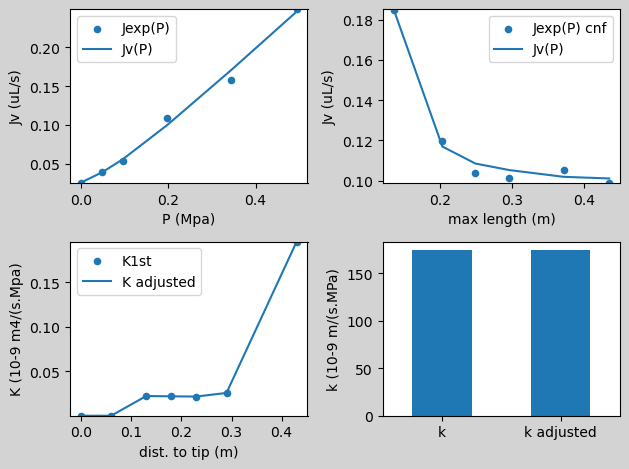

In [2]:
%run example_cut_and_flow_water_solute.py parameters_Ctr-3P2.yml

### Pure water solver

The same input parameter file with the pure water solver (no solute transport).

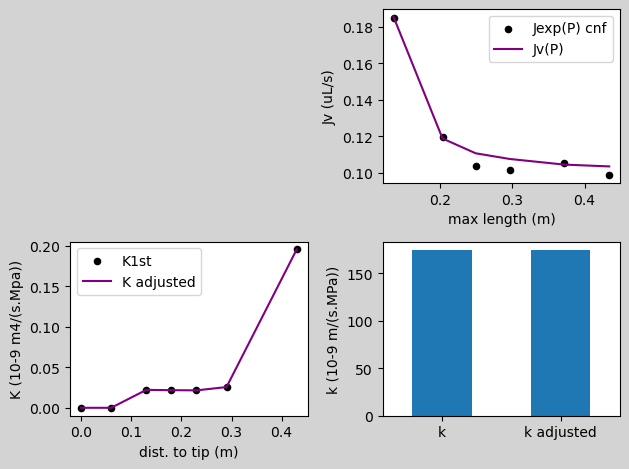

In [3]:
%run example_cut_and_flow_pure_water.py parameters_Ctr-3P2.yml

We can note that the fit of data is not as good as simulation with water-solute solver. Let's do run a fit with pure water solver.

*********** pre_optimization ************************
pre-optimization ar: 9.34e-01
pre-optimization ax: 1.01e+00
****************************************************************
finished minimize K: [ 2.99e-04, 7.19e-04, 3.17e-03, 3.17e-03, 5.07e-03, 5.85e-02, 1.43e-01 ]
finished minimize k0: , 1.63e+02
          plant  cut length (m)  max_length  k (10-9 m/s/MPa)  length (m)  surface (m2)  Jv (uL/s)  Jexp (uL/s)
0  Exp03_P2.txt          0.0000      0.4340        163.141792       3.979      0.005644   0.101705     0.098667
1  Exp03_P2.txt          0.0623      0.3717        163.141792       3.915      0.005432   0.101730     0.105333
2  Exp03_P2.txt          0.1374      0.2966        163.141792       3.829      0.005172   0.102061     0.101444
3  Exp03_P2.txt          0.1847      0.2493        163.141792       3.694      0.004912   0.103611     0.103667
4  Exp03_P2.txt          0.2305      0.2035        163.141792       3.468      0.004547   0.119508     0.119500
5  Exp03_P2.txt       

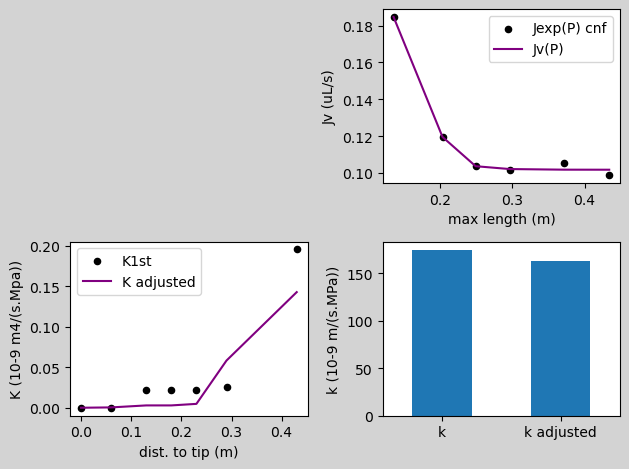

In [4]:
%run example_cut_and_flow_pure_water.py parameters_Ctr-3P2.yml -op -v 

We can note that there are no significant differences between hydraulic parameters from water-solute and pure water solver in control condition.

## Maize root in control condition

#### Solute-water solver

Here an example of a maize root with measurements done in a PEG solution (150 g/l) simulating water stress, in the parameters file `parameters_150-5P13.yml` hydraulic and solute transport parameters have been already optimized to get the best fit.

running time is  1.2109487056732178


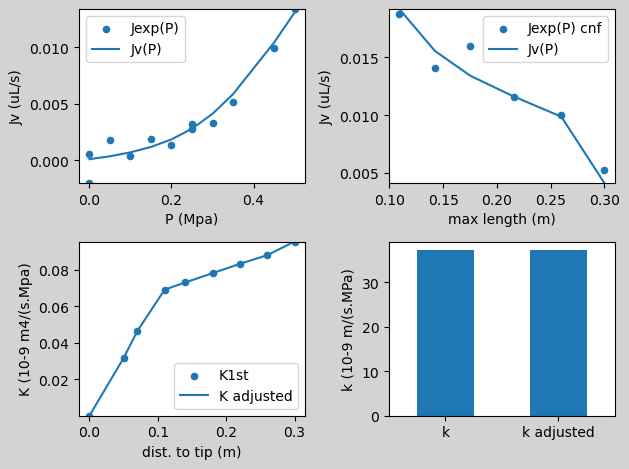

In [5]:
%run example_cut_and_flow_water_solute.py parameters_150-5P13.yml

### pure water solver

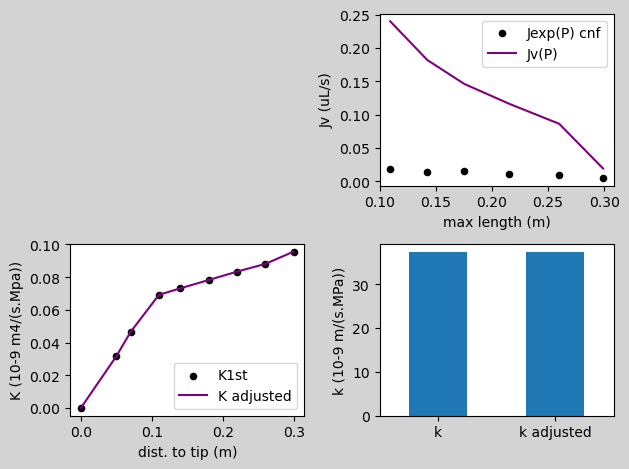

In [6]:
%run example_cut_and_flow_pure_water.py  parameters_150-5P13.yml

Here the fit is very bad. Let's run a parameters optimization with the pure water solver.

*********** pre_optimization ************************
pre-optimization ar: 3.95e-01
pre-optimization ax: 7.70e-02
****************************************************************
finished minimize K: [ 1.71e-07, 3.58e-03, 4.49e-03, 6.54e-03, 6.54e-03, 6.54e-03, 6.54e-03, 6.54e-03, 6.54e-03 ]
finished minimize k0: , 1.40e+01
finished minimize K: [ 2.17e-08, 3.74e-03, 4.66e-03, 6.61e-03, 6.61e-03, 6.61e-03, 6.61e-03, 6.61e-03, 6.61e-03 ]
finished minimize k0: , 1.40e+01
           plant  cut length (m)  max_length  k (10-9 m/s/MPa)  length (m)  surface (m2)  Jv (uL/s)  Jexp (uL/s)
0  Exp05_P13.txt        0.000000    0.299000         14.012456       0.954      0.001796   0.005817     0.005282
1  Exp05_P13.txt        0.039098    0.259902         14.012456       0.913      0.001663   0.009844     0.009976
2  Exp05_P13.txt        0.083459    0.215541         14.012456       0.869      0.001521   0.011526     0.011560
3  Exp05_P13.txt        0.123762    0.175238         14.012456       0.829 

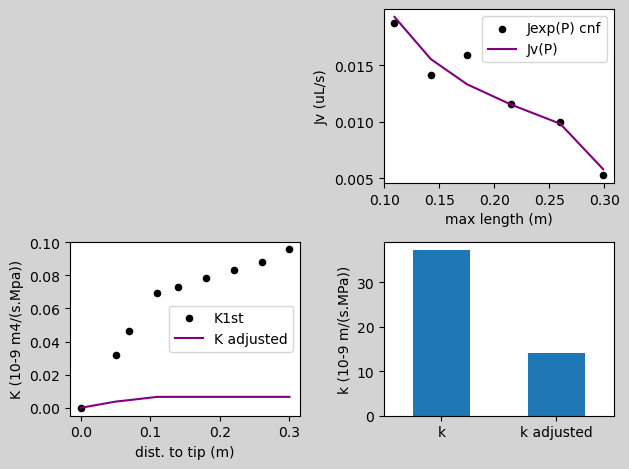

In [7]:
%run example_cut_and_flow_pure_water.py  parameters_150-5P13.yml -op -v

Therefore without taking account for solute transport we make an error of 62 % on k and 93 % on the max of K